In [104]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [105]:
df = pd.read_csv('bank-full.csv', sep = ';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Q1. Preprocessing - Encode categorical variables (job, marital, education, contact, month, poutcome, etc.)

* Scale numerical features (age, balance, duration, campaign, pdays, previous).
    - Which encoding strategy would you choose here: One-Hot Encoding or Label Encoding? Justify.

In [107]:
X = df.drop('y', axis = 1)
y = df['y'].map({'yes': 1, 'no': 0})

In [108]:
binary_cols = ['default', 'housing', 'loan']
for col in binary_cols:
    X[col] = X[col].map({'yes':1, 'no':0})

In [109]:
X['education'].unique()

array(['tertiary', 'secondary', 'unknown', 'primary'], dtype=object)

In [110]:
X['education'] = X['education'].map({'unknown':0, 'primary':1, 'secondary':2, 'tertiary':3})

In [111]:
nominal_cols = ['job', 'marital', 'contact', 'month', 'poutcome']
X = pd.get_dummies(X, columns = nominal_cols)

In [112]:
numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

## Q2. Model Building - Split the dataset (train-test 70:30).

* Train a Logistic Regression model to predict y.
    - Report accuracy, precision, recall, and F1-score.

In [114]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [115]:
model_log = LogisticRegression()
model_log.fit(X_train, y_train)

LogisticRegression()

In [116]:
y_pred = model_log.predict(X_test)

In [117]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Logistic Regression Performance:")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-score :", f1)


Logistic Regression Performance:
Accuracy : 0.8998820406959599
Precision: 0.6411764705882353
Recall   : 0.34105131414267836
F1-score : 0.4452614379084967


In [118]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[11661   305]
 [ 1053   545]]


In [119]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.94     11966
           1       0.64      0.34      0.45      1598

    accuracy                           0.90     13564
   macro avg       0.78      0.66      0.70     13564
weighted avg       0.88      0.90      0.89     13564



## Checking Class Imbalance

In [121]:
print("Target distribution:\n", y.value_counts())
print("\nTarget distribution (percentage):\n", y.value_counts(normalize=True) * 100)

Target distribution:
 y
0    39922
1     5289
Name: count, dtype: int64

Target distribution (percentage):
 y
0    88.30152
1    11.69848
Name: proportion, dtype: float64


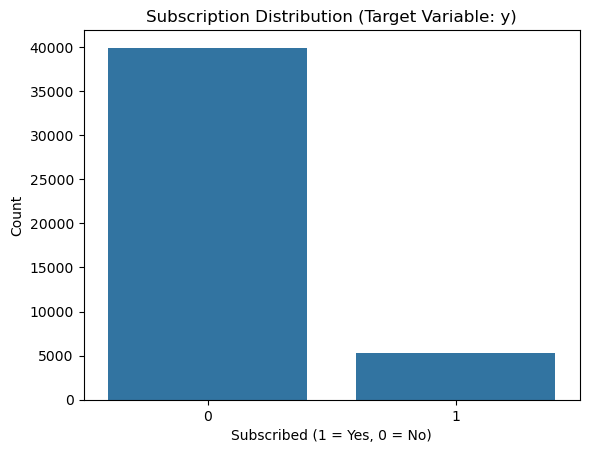

In [122]:
sns.countplot(x=y)
plt.title("Subscription Distribution (Target Variable: y)")
plt.xlabel("Subscribed (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()


## Q3. Feature Importance - Extract feature coefficients from Logistic Regression.
    - Which features are most positively/negatively associated with subscription? Interpret them.

In [124]:
feature_names = X_train.columns
coefficients = model_log.coef_[0]

feature_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
feature_importance = feature_importance.sort_values(by="Coefficient", ascending=False)

print(feature_importance.head(10), '\n')   
print(feature_importance.tail(10)) 

             Feature  Coefficient
43  poutcome_success     1.509399
36         month_mar     1.428331
7           duration     1.079135
39         month_oct     0.839160
40         month_sep     0.780956
31         month_dec     0.474500
19       job_student     0.426453
26  contact_cellular     0.309392
35         month_jun     0.305645
16       job_retired     0.273050 

             Feature  Coefficient
37         month_may    -0.488891
42    poutcome_other    -0.589019
4            housing    -0.701545
30         month_aug    -0.753481
41  poutcome_failure    -0.816092
44  poutcome_unknown    -0.887943
38         month_nov    -0.894406
34         month_jul    -0.916907
33         month_jan    -1.283122
28   contact_unknown    -1.291626


## Q4. Model Comparison - Train a Decision Tree Classifier and compare with Logistic Regression.
- Which model performs better? Does the tree overfit?

In [126]:
from sklearn.tree import DecisionTreeClassifier

In [127]:
model_dt = DecisionTreeClassifier()
model_dt.fit(X_train, y_train)


DecisionTreeClassifier()

In [128]:
y_pred_dt = model_dt.predict(X_test)

In [129]:
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Performance:")
print("Accuracy :", acc_dt)
print("Precision:", prec_dt)
print("Recall   :", rec_dt)
print("F1-score :", f1_dt)


Decision Tree Performance:
Accuracy : 0.8758478324977883
Precision: 0.47332506203473945
Recall   : 0.47747183979974966
F1-score : 0.4753894080996885


In [130]:
print("\nLogistic Regression vs Decision Tree")
print(f"LogReg → Acc: {acc:.3f}, Prec: {prec:.3f}, Rec: {rec:.3f}, F1: {f1:.3f}")
print(f"DecTree → Acc: {acc_dt:.3f}, Prec: {prec_dt:.3f}, Rec: {rec_dt:.3f}, F1: {f1_dt:.3f}")



Logistic Regression vs Decision Tree
LogReg → Acc: 0.900, Prec: 0.641, Rec: 0.341, F1: 0.445
DecTree → Acc: 0.876, Prec: 0.473, Rec: 0.477, F1: 0.475
